In [1]:
# Load required modules
#%matplotlib inline

#from IPython.display import display

import numpy as np


from PIL import Image


#For plotting
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.rcParams["animation.html"] = "jshtml"
mpl.rcParams['figure.facecolor'] = 'white'

# Import relevant modules from within GPU Ocean
from gpuocean.SWEsimulators import GPUOceanSim
from gpuocean.utils import IPythonMagic, NetCDFInitialization, PlotHelper, DrifterPlotHelper
from gpuocean.utils import Common, BathymetryAndICs
from gpuocean.drifters import LagrangianUtils

# Need pycuda to do things from scratch
import pycuda.driver as cuda


from importlib import reload

In [2]:
# Create the GPU context
%cuda_context_handler gpu_ctx

In [3]:
def imshow1(data, title=""):
    fig = plt.figure(figsize=(4, 4))
    data_max = np.max(np.abs(data))
    sp = plt.imshow(data, interpolation="none", origin='lower', 
                            cmap=plt.cm.BrBG, vmin=-data_max, vmax=data_max)
    plt.colorbar(sp, shrink=0.9)
    plt.axis('image')
    plt.title(title)

In [4]:
def imshow_image(data, title="", vmin=0, vmax=255):
    fig = plt.figure(figsize=(4, 4))
    data_max = np.max(np.abs(data))
    sp = plt.imshow(data, interpolation="none", vmin=vmin, vmax=vmax)
    plt.colorbar(sp, shrink=0.9)
    plt.axis('image')
    plt.title(title)

(365, 1103)


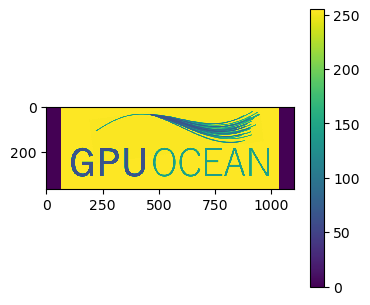

In [5]:
# Load the image
image_path = '../logo\gpuocean-logo.png'  # Replace with your image file path
input_image = Image.open(image_path)

# Convert the image to grayscale
gray_image = input_image.convert('L')

# Convert the grayscale image to a numpy array
image_array = np.array(gray_image)
print(image_array.shape)
imshow_image(image_array)


Test table lookup of exact values

<PIL.Image.Image image mode=L size=100x50 at 0x1CAEF6D8308>
(50, 100)


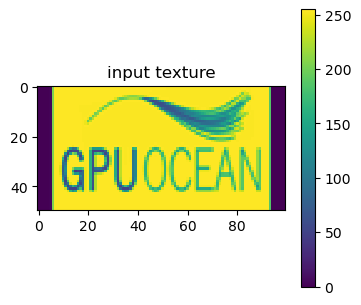

In [26]:
# Define a small domain 
ny, nx = 50, 100

ny_tex, nx_tex = 50, 100

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
print(gray_image_resized)
test_image = gray_image.resize((nx_tex, ny_tex))
tex_image = np.array(gray_image_resized)
original_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())

In [20]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

c:\Users\jakobt\AppData\Local\miniconda3\envs\gpuocean\lib\site-packages\ipykernel_launcher.py:32: UserWarning: The CUDA compiler succeeded, but said the following:
kernel.cu



In [21]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [22]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(50, 100)
(50, 100)
(50, 100)
(50, 100)
data image
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
sampled image
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
tex sampled image
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


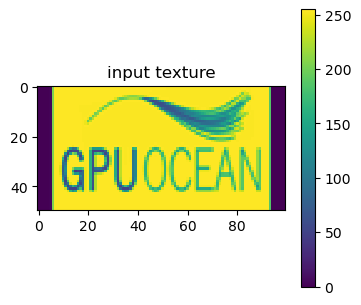

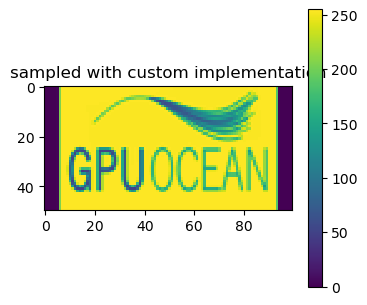

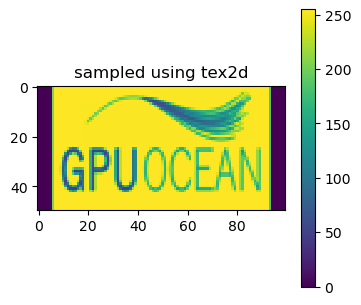

In [23]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

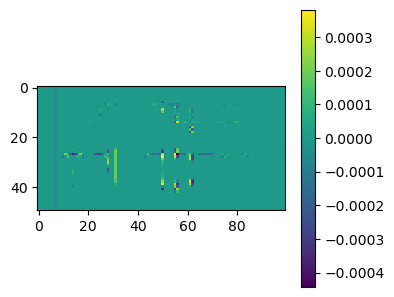

In [24]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

1.2893676e-07


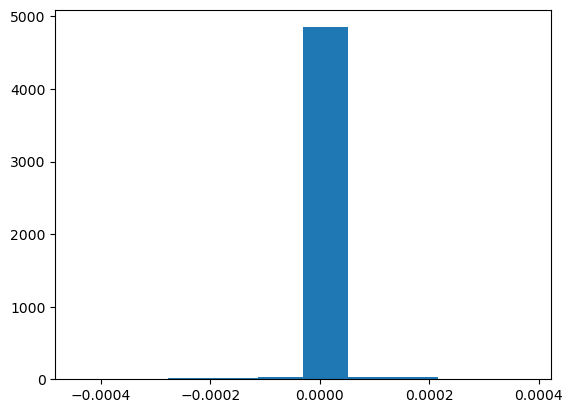

In [27]:
plt.hist(diff.flatten())
print(diff.mean())

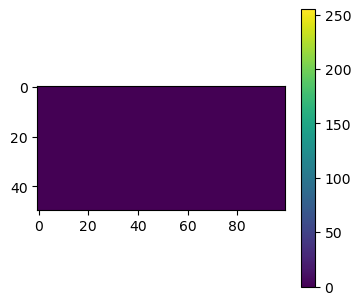

In [28]:
diff2 = image_host - original_image
imshow_image(diff2)

1.2893676e-07


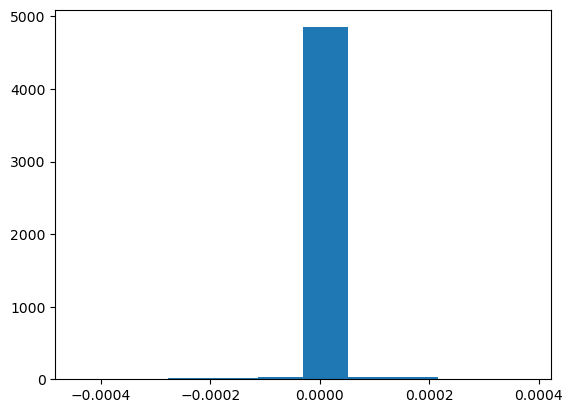

In [29]:
plt.hist(diff2.flatten())
print(diff2.mean())

Test downsampling

<PIL.Image.Image image mode=L size=8x4 at 0x1CAF0BA2F48>
(4, 8)


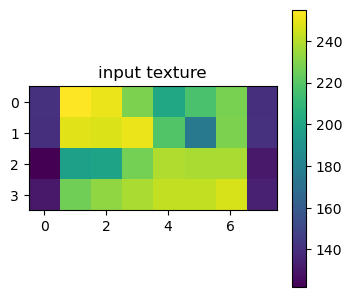

In [30]:
# Define a small domain 
ny, nx = 2, 4

ny_tex, nx_tex = 4, 8

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
print(gray_image_resized)
test_image = gray_image.resize((nx_tex, ny_tex))
tex_image = np.array(gray_image_resized)
original_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())

In [31]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [32]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [33]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(2, 4)
(2, 4)
(2, 4)
(2, 4)
data image
 [[141 255 251 229 202 217 228 140]
 [140 249 248 251 219 176 229 141]
 [122 197 199 227 239 238 238 131]
 [131 226 233 238 243 243 247 134]]
sampled image
 [[141.      243.66666 212.      140.     ]
 [131.      234.66667 243.      134.     ]]
tex sampled image
 [[196.25 244.75 203.5  184.5 ]
 [169.   224.25 240.75 187.5 ]]


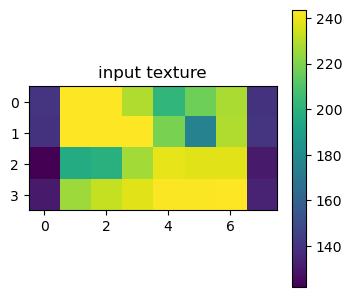

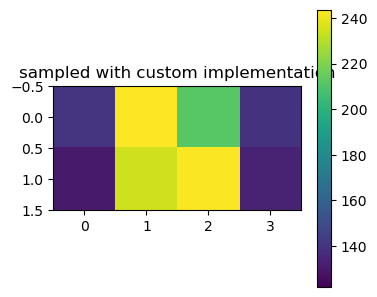

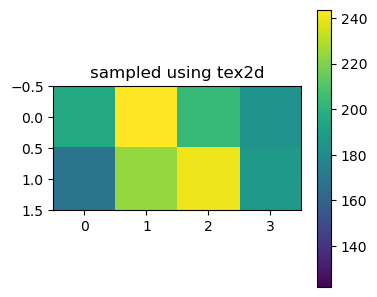

In [34]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)


vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

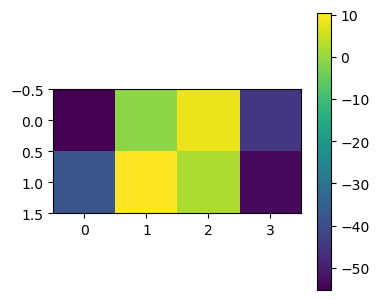

In [35]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

-21.395834


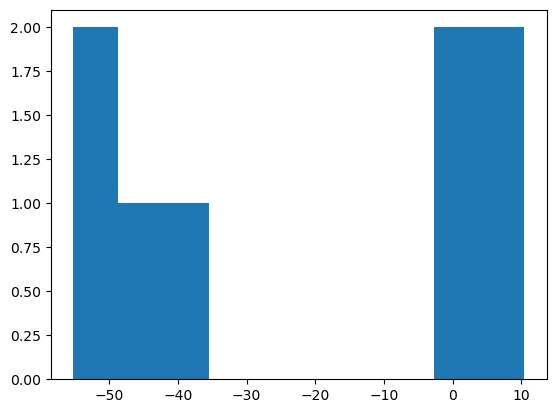

In [36]:
plt.hist(diff.flatten())
print(diff.mean())

Test upsampling

<PIL.Image.Image image mode=L size=4x2 at 0x1CAF0900BC8>
(2, 4)


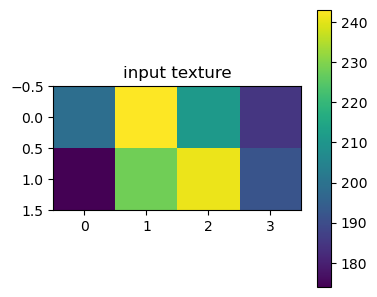

In [37]:
# Define a small domain 
ny, nx = 4, 8

ny_tex, nx_tex = 2, 4

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
print(gray_image_resized)
test_image = gray_image.resize((nx_tex, ny_tex))
tex_image = np.array(gray_image_resized)
original_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())

In [38]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [39]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [40]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(4, 8)
(4, 8)
(4, 8)
(4, 8)
data image
 [[199 243 211 185]
 [174 228 241 192]]
sampled image
 [[199.      217.85715 236.7143  233.85715 220.14285 207.28572 196.14285
  185.     ]
 [190.66667 210.9524  231.23811 233.14287 225.85715 216.19049 201.7619
  187.33333]
 [182.33333 204.04762 225.7619  232.42857 231.57143 225.09525 207.38095
  189.66667]
 [174.      197.14285 220.28572 231.71428 237.28572 234.      213.
  192.     ]]
tex sampled image
 [[199.     210.     232.     235.     219.     204.5    191.5    185.    ]
 [192.75   204.375  227.625  234.0625 223.6875 210.5625 194.6875 186.75  ]
 [180.25   193.125  218.875  232.1875 233.0625 222.6875 201.0625 190.25  ]
 [174.     187.5    214.5    231.25   237.75   228.75   204.25   192.    ]]


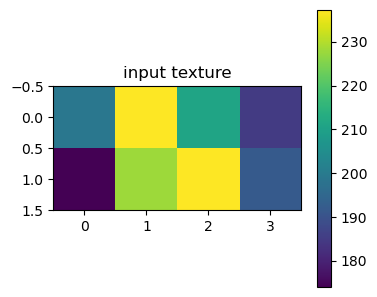

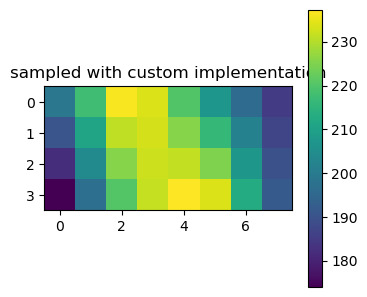

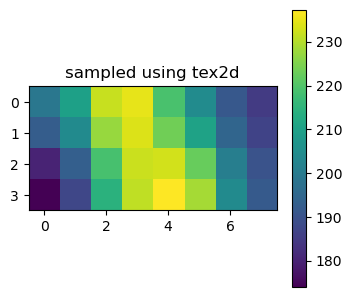

In [41]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

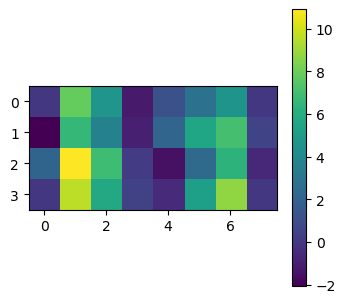

In [42]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

3.0892882


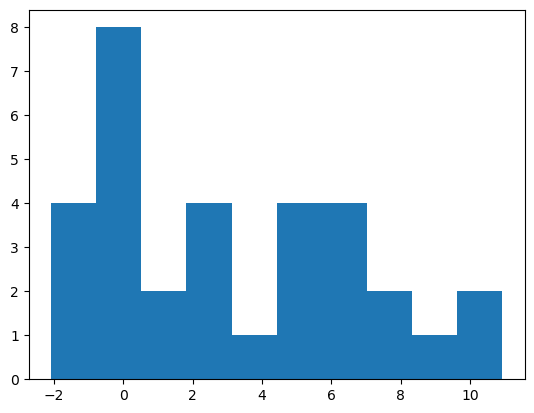

In [43]:
plt.hist(diff.flatten())
print(diff.mean())

Test upsample to larger images

<PIL.Image.Image image mode=L size=4x2 at 0x1CAEF78F1C8>
(2, 4)


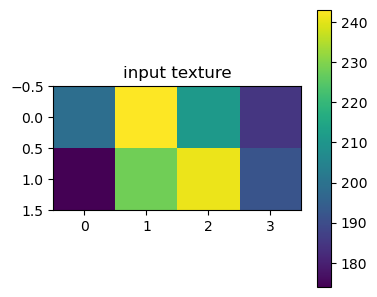

In [44]:
# Define a small domain 
ny, nx = 50, 100

ny_tex, nx_tex = 2, 4

gray_image_resized = gray_image.resize((nx_tex, ny_tex))
print(gray_image_resized)
test_image = gray_image.resize((nx_tex, ny_tex))
tex_image = np.array(gray_image_resized)
original_image = np.array(gray_image_resized)

image_init = np.zeros((ny, nx))

print(tex_image.shape)

imshow_image(tex_image, "input texture", vmin=tex_image.min(), vmax=tex_image.max())


In [45]:
# GPU stuff
gpu_ctx = gpu_ctx
gpu_stream = cuda.Stream() # Different streams can in principle be run in parallel

# Define how we want to distribute the work on the GPU
# Here, we assume that each thread is responsible for moving one drifter
# Local size refers to the number of threads in each block (organized in 3D)
# global size refers to the number of blocks that will be run on the GPU (can be organized in 2D or 3D)
block_width = 16 
block_height = 16

local_size = (block_width, block_height, 1)
global_size = (int(np.ceil(nx / block_width)), int(np.ceil(ny / block_height)), 1)


# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

tex_image_device = Common.CUDAArray2D(gpu_stream,
                                nx, ny, 0, 0,
                                image_init)

# Allocate GPU memory and intialize using the 2D Array utility function, which is a wrapper around pycuda.gpuarray
image_data_array_device = Common.CUDAArray2D(gpu_stream,
                                nx_tex, ny_tex, 0, 0,
                                tex_image)

# Compile cuda file
kernel = gpu_ctx.get_kernel("test_tex2d.cu", \
                                defines={'block_width': block_width, 'block_height': block_height
                                        })

# Get CUDA functions and define data types for prepared_{async_}call()
interpTestKernel = kernel.get_function("interpTest")
interpTestKernel.prepare("iiPiPiPii")

In [46]:
# Texture for image
image_texref = kernel.get_texref("data_tex")

#Upload data to GPU and bind to texture reference
image_texref.set_array(cuda.np_to_array(np.ascontiguousarray(tex_image, dtype=np.float32), order="C"))
            
# Set texture parameters
image_texref.set_filter_mode(cuda.filter_mode.LINEAR) #bilinear interpolation
image_texref.set_address_mode(0, cuda.address_mode.CLAMP) #no indexing outside domain
image_texref.set_address_mode(1, cuda.address_mode.CLAMP)
image_texref.set_flags(cuda.TRSF_NORMALIZED_COORDINATES) #Use [0, 1] indexing

In [47]:
interpTestKernel.prepared_async_call(global_size, local_size, gpu_stream,
                                               nx, ny,
                                               image_device.data.gpudata, image_device.pitch,
                                               tex_image_device.data.gpudata, tex_image_device.pitch,
                                               image_data_array_device.data.gpudata, image_data_array_device.nx, image_data_array_device.ny
                                             )

(50, 100)
(50, 100)
(50, 100)
(50, 100)
data image
 [[199 243 211 185]
 [174 228 241 192]]
sampled image
 [[199.      200.33333 201.66667 ... 186.57576 185.78787 185.     ]
 [198.48979 199.8293  201.16884 ... 186.74707 185.94495 185.14285]
 [197.9796  199.3253  200.671   ... 186.91837 186.10204 185.28572]
 ...
 [175.0204  176.6444  178.2684  ... 194.62709 193.17068 191.71428]
 [174.51021 176.14038 177.77057 ... 194.7984  193.32776 191.85715]
 [174.      175.63637 177.27272 ... 194.9697  193.48485 192.     ]]
tex sampled image
 [[199. 199. 199. ... 185. 185. 185.]
 [199. 199. 199. ... 185. 185. 185.]
 [199. 199. 199. ... 185. 185. 185.]
 ...
 [174. 174. 174. ... 192. 192. 192.]
 [174. 174. 174. ... 192. 192. 192.]
 [174. 174. 174. ... 192. 192. 192.]]


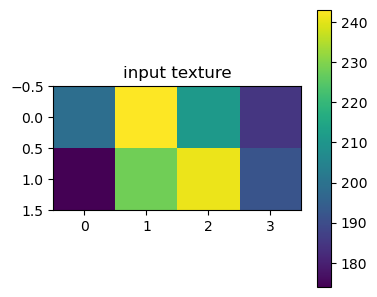

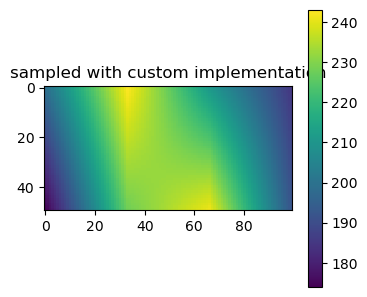

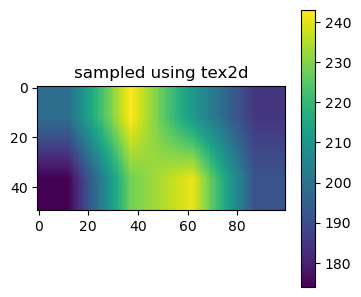

In [48]:
image_host = image_device.download(gpu_stream)
tex_image_host = tex_image_device.download(gpu_stream)
print(image_init.shape)
print(image_device.data.shape)
print(tex_image_device.data.shape)
print(image_host.shape)

vmin = np.min(np.array([np.min(tex_image), np.min(image_host), np.min(tex_image_host)]))
vmax = np.min(np.array([np.max(tex_image), np.max(image_host), np.max(tex_image_host)]))
imshow_image(tex_image, "input texture", vmin, vmax)
imshow_image(image_host, "sampled with custom implementation", vmin, vmax)
imshow_image(tex_image_host, "sampled using tex2d", vmin, vmax)

print("data image\n", tex_image)
print("sampled image\n", image_host)
print("tex sampled image\n", tex_image_host)

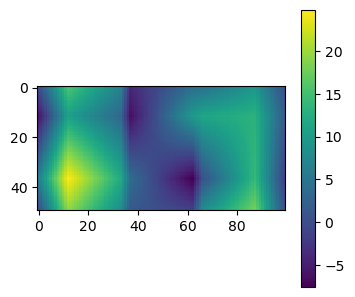

In [49]:
diff = image_host - tex_image_host
imshow_image(diff, vmin=diff.min(), vmax=diff.max())

6.9200006


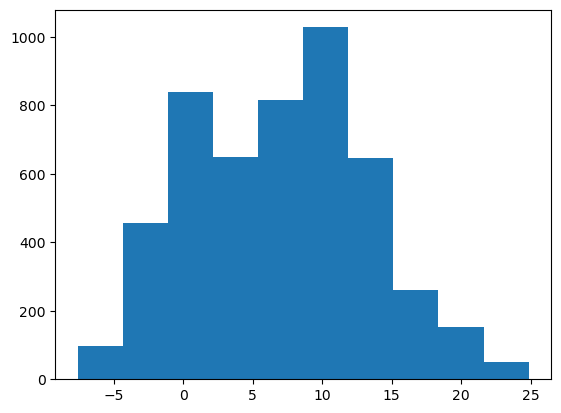

In [50]:
plt.hist(diff.flatten())
print(diff.mean())